In [ ]:

from sklearn.metrics import accuracy_score
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import KFold, StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor


In [ ]:
from optuna.visualization import plot_optimization_history
import warnings
import optuna
# Configurazione
optuna.logging.set_verbosity(optuna.logging.WARNING)
warnings.filterwarnings('ignore')


In [2]:
import sys
print(sys.executable)
print(sys.version)

c:\Users\compu\AppData\Local\Programs\Python\Python311\python.exe
3.11.0rc2 (main, Sep 11 2022, 20:22:52) [MSC v.1933 64 bit (AMD64)]


In [3]:
#carica il dataset
data = fetch_california_housing(as_frame=True)
df = data.frame


In [4]:
df.head()
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [5]:
numeri = df.select_dtypes(include=np.number) #prendo solo le colonne numeriche
columns = numeri.columns



quartili a 25 e 75

In [6]:
#quartili
Q1 = numeri.quantile(0.20)
Q3 = numeri.quantile(0.70)
IQR = Q3 - Q1
df_clean= numeri[~((numeri < (Q1 - 1.5 * IQR)) |(numeri > (Q3 + 1.5 * IQR))).any(axis=1)]


In [7]:
#Split iniziale

x = df.drop('MedHouseVal', axis=1)
y = df['MedHouseVal']

X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

print(f"Train Set: {X_train.shape}, Test Set: {X_test.shape}")


Train Set: (16512, 8), Test Set: (4128, 8)


In [8]:
#Feature Engineering
#vogliamo catturare le curve, solo rette
# include_bias=False perchè l'intercetta è già inclusa nel modello
from sklearn.preprocessing import PolynomialFeatures
print("\n-----Espansione polinomiale-----")

poly = PolynomialFeatures(degree=2, include_bias=False)
#fill solo per il train
X_train_poly = poly.fit_transform(X_train)

#transform anche per il test
X_test_poly = poly.transform(X_test)

print(f"Nuove dimensioni del train set: {X_train_poly.shape}")


-----Espansione polinomiale-----
Nuove dimensioni del train set: (16512, 44)


In [9]:
#Fase 3: scaling (standardizzazione)
#fondamentale per ridge: se abbiamo x e x^2, x^2 sarà enorme.
print("\n-----Standardizzazione-----")
scaler = StandardScaler()

#fit solo su train (calcola media e deviazione standard)
X_train_scaled = scaler.fit_transform(X_train_poly)

#transform su test 
#se facessimo fit sul test, sarebbe data leakage
X_test_scaled = scaler.transform(X_test_poly)
print("Standardizzazione completata.")


-----Standardizzazione-----
Standardizzazione completata.


In [10]:
#Modellazione con Ridge Regression e Confronto lineare
print("\n-----Addestramento Modelli-----")

#Modello A: Regressione Lineare
from sklearn.linear_model import Ridge, LinearRegression, Lasso
model_linear = LinearRegression()
model_linear.fit(X_train_scaled, y_train)
y_pred_linear = model_linear.predict(X_test_scaled)

#Modello B: Ridge Regression
model_ridge = Lasso(alpha=0.02)

model_ridge.fit(X_train_scaled, y_train)
y_pred_ridge = model_ridge.predict(X_test_scaled)



-----Addestramento Modelli-----


c:\Users\compu\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.275e+00, tolerance: 2.207e+00
  model = cd_fast.enet_coordinate_descent(


In [11]:
#Fase 5: valutazione e confronto
from sklearn.metrics import mean_squared_error, r2_score
print("\n-----Risultati sul Test Set-----")

#metriche modello lineare
rmse_linear = np.sqrt(mean_squared_error(y_test, y_pred_linear))
r2_linear = r2_score(y_test, y_pred_linear)
print(f"Modello Lineare - RMSE: {rmse_linear:.4f}, R2: {r2_linear:.4f}")

#metriche modello ridge
rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
r2_ridge = r2_score(y_test, y_pred_ridge)
print(f"Ridge Regression - RMSE: {rmse_ridge:.4f}, R2: {r2_ridge:.4f}")

#calcolo il miglioramento 
improvement = (rmse_linear - rmse_ridge) / rmse_linear * 100
print(f"Miglioramento RMSE con Ridge: {improvement:.2f}%")


-----Risultati sul Test Set-----
Modello Lineare - RMSE: 0.6814, R2: 0.6457
Ridge Regression - RMSE: 0.7541, R2: 0.5660
Miglioramento RMSE con Ridge: -10.68%


In [12]:
from sklearn.linear_model import ElasticNet
from sklearn.metrics import mean_squared_error, r2_score

model_elastic = ElasticNet(alpha=0.02, l1_ratio=0.5)
model_elastic.fit(X_train_scaled, y_train)
y_pred = model_elastic.predict(X_test_scaled)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print ("MSE:", mse)
print ("R2:", r2)

MSE: 0.568761107613964
R2: 0.5659667195065528


In [13]:
# creazione della nuova feature
df['BedroomsRatio'] = df['AveBedrms'] / (df['AveRooms'] + 1e-6)

# selezione delle feature X 
X = df[['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude', 'BedroomsRatio']]
y = df['MedHouseVal']

#train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Train Set: {X_train.shape}, Test Set: {X_test.shape}")

#scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#modello lasso
model_lasso = Lasso(alpha=0.02)
model_lasso.fit(X_train_scaled, y_train)

# predizioni e metriche
y_pred_lasso = model_lasso.predict(X_test_scaled)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MSE:", mse)
print("R2:", r2)


Train Set: (16512, 9), Test Set: (4128, 9)
MSE: 0.568761107613964
R2: 0.5659667195065528


In [14]:
# train test split
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

#scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#alleniamo modello ridge
model_lasso = Ridge(alpha=0.02)
model_lasso.fit(X_train_scaled, y_train)

#predizione
y_pred = model_lasso.predict(X_test_scaled)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MSE:", mse)
print("R2:", r2)




MSE: 0.5558908615364845
R2: 0.5757882685734377


In [15]:
#xgboost regressor
#oulier removal con IQR
def remove_outliers_iqr(X, y):
    mask = pd.Series(True, index=X.index)
    
    for col in X.columns:
        Q1 = X[col].quantile(0.25)
        Q3 = X[col].quantile(0.75)
        IQR = Q3 - Q1
        col_mask = ~((X[col] < (Q1 - 1.5 * IQR)) | (X[col] > (Q3 + 1.5 * IQR)))
        mask &= col_mask
    return X[mask], y[mask]

X_train_clean, y_train_clean = remove_outliers_iqr(x, y)
print(f"Train Set after outlier removal: {X_train_clean.shape}")


Train Set after outlier removal: (16842, 8)


In [16]:
model = XGBRegressor(
    objective='reg:squarederror',
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

model.fit(X_train_clean, y_train_clean)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [17]:
#valutazione senza outlier removal

y_pred = model.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("RMSE:", rmse)
print("R2:", r2)

RMSE: 0.3950354730305965
R2: 0.8809127321746577


In [18]:
#confronto senza outlier removal

model_raw = XGBRegressor(
    objective='reg:squarederror',
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

model_raw.fit(X_train, y_train)
y_pred_raw = model_raw.predict(X_test)
rmse_raw = np.sqrt(mean_squared_error(y_test, y_pred_raw))
r2_raw = r2_score(y_test, y_pred_raw)
print("Senza Outlier Removal - RMSE:", rmse_raw)
print("Senza Outlier Removal - R2:", r2_raw)


Senza Outlier Removal - RMSE: 0.4549525711763628
Senza Outlier Removal - R2: 0.8420479060683504


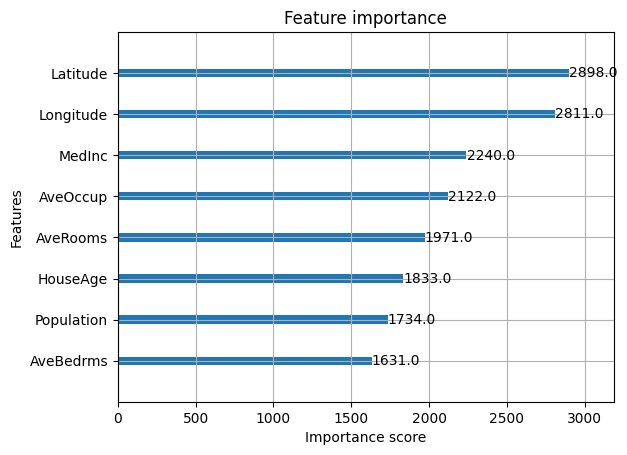

In [19]:
#feature importance

from xgboost import plot_importance

plot_importance(model, max_num_features=10)
plt.show()


In [20]:
import optuna
from xgboost import XGBRegressor
from sklearn.model_selection import cross_val_score

def objective(trial):
    param = {
        "n_estimators": trial.suggest_int("n_estimators", 200, 800),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        "reg_alpha": trial.suggest_float("reg_alpha", 0.0, 1.0),
        "reg_lambda": trial.suggest_float("reg_lambda", 1.0, 10.0),
        "objective": "reg:squarederror",
        "random_state": 42,
        "n_jobs": -1
    }
    
    model = XGBRegressor(**param)
    scores = cross_val_score(
        model, 
        X_train_clean, 
        y_train_clean, 
        cv=3, 
        scoring='neg_mean_squared_error',
        n_jobs=-1
    )
    return -scores.mean()

# ottimizzazione con Optuna

study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=50)

print("Migliori parametri:")
print(study.best_params)
print("Miglior RMSE CV:", study.best_value)


c:\Users\compu\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[I 2025-12-09 16:57:54,136] A new study created in memory with name: no-name-c921294b-7013-4eaa-a3bd-b8a244e6ca78
[I 2025-12-09 16:58:04,114] Trial 0 finished with value: 0.4746997058482632 and parameters: {'n_estimators': 389, 'max_depth': 10, 'learning_rate': 0.06147704318398879, 'subsample': 0.9086367137125211, 'colsample_bytree': 0.6951449295945865, 'min_child_weight': 3, 'reg_alpha': 0.41423672934398703, 'reg_lambda': 1.343882895509243}. Best is trial 0 with value: 0.4746997058482632.
[I 2025-12-09 16:58:08,731] Trial 1 finished with value: 0.4902089419938534 and parameters: {'n_estimators': 286, 'max_depth': 7, 'learning_rate': 0.17360166679493894, 'subsample': 0.6709395546940503, 'colsample_bytree': 0.6672

Migliori parametri:
{'n_estimators': 471, 'max_depth': 3, 'learning_rate': 0.047323133857556265, 'subsample': 0.7406401790644805, 'colsample_bytree': 0.9995075443257664, 'min_child_weight': 9, 'reg_alpha': 0.3295226207967392, 'reg_lambda': 4.781272384102713}
Miglior RMSE CV: 0.40552199310068565


In [21]:
#modello finale con parametri ottimizzati

best_model = XGBRegressor(
    # study.best_params significa che stiamo passando 
    # tutti i parametri ottimizzati trovati da Optuna 
    # (mettiamo i ** per unpacking)
    **study.best_params,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

best_model.fit(X_train_clean, y_train_clean)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.9995075443257664
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [22]:
#valutazione test

y_pred = best_model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("RMSE Test:", rmse)
print("R2 Test:", r2)

RMSE Test: 0.4889174699688107
R2 Test: 0.8175834442453287


In [29]:
# --- B. LIGHTGBM ---
import lightgbm as lgb
def objective_lgb(trial, X, y):
    # LightGBM usa 'num_leaves' invece di depth come parametro principale
    params = {
        'objective': 'regression',
        'metric': 'rmse',
        'verbosity': -1,
        'boosting_type': 'gbdt',
        'n_jobs': -1,
        # Spazio di ricerca
        'num_leaves': trial.suggest_int('num_leaves', 20, 150),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 100),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 0.95),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 0.95),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
    }

    dtrain = lgb.Dataset(X, label=y)
    
    # LightGBM CV
    cv_results = lgb.cv(
        params, dtrain, num_boost_round=1000, nfold=3,
        stratified=False, callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False)],
        seed=42
    )
    
    # LGBM restituisce una lista di metriche, prendiamo l'ultima (migliore grazie a early stop)
    best_score = cv_results['valid rmse-mean'][-1]
    trial.set_user_attr("n_estimators", len(cv_results['valid rmse-mean']))
    return best_score

print("\n--- Ottimizzazione LightGBM con Optuna ---")
study_lgb = optuna.create_study(direction='minimize')
study_lgb.optimize(lambda trial: objective_lgb(trial, X_train_clean, y_train_clean), n_trials=30)

print("Migliori parametri LightGBM:")
print(study_lgb.best_params)
print("Miglior RMSE CV LightGBM:", study_lgb.best_value)
print(study_lgb.best_params)

[I 2025-12-09 17:49:25,704] A new study created in memory with name: no-name-9781e1bf-3ecc-43bb-b183-9d30f0ea2868



--- Ottimizzazione LightGBM con Optuna ---


[I 2025-12-09 17:49:36,140] Trial 0 finished with value: 0.4304176792327424 and parameters: {'num_leaves': 87, 'min_child_samples': 8, 'learning_rate': 0.038232455619109734, 'subsample': 0.7633835781641786, 'colsample_bytree': 0.8418399818295801, 'reg_alpha': 2.3771183003390277, 'reg_lambda': 1.700755726910544e-06}. Best is trial 0 with value: 0.4304176792327424.
[I 2025-12-09 17:49:40,483] Trial 1 finished with value: 0.43181380683015264 and parameters: {'num_leaves': 33, 'min_child_samples': 63, 'learning_rate': 0.05650848348753074, 'subsample': 0.9252152348976397, 'colsample_bytree': 0.6409607572587206, 'reg_alpha': 8.01989715659195e-06, 'reg_lambda': 0.009839257736930998}. Best is trial 0 with value: 0.4304176792327424.
[I 2025-12-09 17:49:47,758] Trial 2 finished with value: 0.4413824512740701 and parameters: {'num_leaves': 121, 'min_child_samples': 26, 'learning_rate': 0.04248860183921147, 'subsample': 0.8805534533452144, 'colsample_bytree': 0.9494446300609847, 'reg_alpha': 3.481

Migliori parametri LightGBM:
{'num_leaves': 80, 'min_child_samples': 11, 'learning_rate': 0.031155171351678265, 'subsample': 0.7515718467693594, 'colsample_bytree': 0.8097821073456587, 'reg_alpha': 9.716048567628273e-05, 'reg_lambda': 1.696545837373232}
Miglior RMSE CV LightGBM: 0.42441859733383963
{'num_leaves': 80, 'min_child_samples': 11, 'learning_rate': 0.031155171351678265, 'subsample': 0.7515718467693594, 'colsample_bytree': 0.8097821073456587, 'reg_alpha': 9.716048567628273e-05, 'reg_lambda': 1.696545837373232}


In [24]:
# --- C. CatBoost ---
# Nota: CatBoost in CV pura è lento. Riduciamo leggermente lo spazio o i trial.
import catboost
from catboost import CatBoostRegressor
def objective_cat(trial):
    params = {
        'iterations': trial.suggest_int('iterations', 600, 1200),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1),
        'depth': trial.suggest_int('depth', 4, 10),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1, 10),
        'subsample': trial.suggest_float('subsample', 0.6, 0.95),
        'verbose': 0, 'allow_writing_files': False, 'random_state': 42
    }
    model = CatBoostRegressor(**params)
    # CatBoost gestisce il multiprocessing diversamente, n_jobs=-1 in cross_val_score a volte conflict
    kf = KFold(n_splits=3, shuffle=True, random_state=42)
    scores = cross_val_score(model, X_train, y_train, cv= kf, scoring='neg_root_mean_squared_error', n_jobs=1)
    return -scores.mean()

print("\n--- Ottimizzazione CatBoost con Optuna ---")
study_cat = optuna.create_study(direction='minimize')
study_cat.optimize(objective_cat, n_trials=30)
print("Migliori parametri CatBoost:")
print(study_cat.best_params)
print("Miglior RMSE CV CatBoost:", study_cat.best_value)

[I 2025-12-09 17:10:07,879] A new study created in memory with name: no-name-fe168133-eb07-46df-8ad1-370680bb2d37



--- Ottimizzazione CatBoost con Optuna ---


[I 2025-12-09 17:10:37,599] Trial 0 finished with value: 0.45147938770172175 and parameters: {'iterations': 1099, 'learning_rate': 0.039942869230502845, 'depth': 8, 'l2_leaf_reg': 3.394694744475669, 'subsample': 0.7986317689635718}. Best is trial 0 with value: 0.45147938770172175.
[I 2025-12-09 17:10:48,418] Trial 1 finished with value: 0.45151875158129257 and parameters: {'iterations': 652, 'learning_rate': 0.07733021705214531, 'depth': 7, 'l2_leaf_reg': 1.9569511467906895, 'subsample': 0.9048647967527221}. Best is trial 0 with value: 0.45147938770172175.
[I 2025-12-09 17:11:06,080] Trial 2 finished with value: 0.46743905552649184 and parameters: {'iterations': 963, 'learning_rate': 0.02597237975641402, 'depth': 7, 'l2_leaf_reg': 4.786413042053686, 'subsample': 0.8094120318805702}. Best is trial 0 with value: 0.45147938770172175.
[I 2025-12-09 17:12:39,082] Trial 3 finished with value: 0.4503959688206017 and parameters: {'iterations': 1026, 'learning_rate': 0.07851947730491854, 'depth

Migliori parametri CatBoost:
{'iterations': 1126, 'learning_rate': 0.08562895834861006, 'depth': 9, 'l2_leaf_reg': 1.597677558276799, 'subsample': 0.818433250677829}
Miglior RMSE CV CatBoost: 0.4453887859141889


In [25]:
print(" -> Optimizing CatBoost (potrebbe richiedere tempo)...")
study_cat = optuna.create_study(direction='minimize')
study_cat.optimize(objective_cat, n_trials=10) # Meno trial per CatBoost che è lento

print(f"\nBEST CV RMSE -> XGB: {study.best_value:.4f} | LGBM: {study_lgb.best_value:.4f} | CAT: {study_cat.best_value:.4f}")


[I 2025-12-09 17:27:10,982] A new study created in memory with name: no-name-2c22d005-4c49-424c-b964-e5d0765934f4


 -> Optimizing CatBoost (potrebbe richiedere tempo)...


[I 2025-12-09 17:27:17,545] Trial 0 finished with value: 0.46633659448082393 and parameters: {'iterations': 818, 'learning_rate': 0.09255121418036076, 'depth': 4, 'l2_leaf_reg': 7.350086662941946, 'subsample': 0.8229033573867862}. Best is trial 0 with value: 0.46633659448082393.
[I 2025-12-09 17:27:23,753] Trial 1 finished with value: 0.4653997658445539 and parameters: {'iterations': 619, 'learning_rate': 0.07744151955412516, 'depth': 5, 'l2_leaf_reg': 5.283573335600818, 'subsample': 0.7892531843794941}. Best is trial 1 with value: 0.4653997658445539.
[I 2025-12-09 17:27:35,700] Trial 2 finished with value: 0.48307967204175384 and parameters: {'iterations': 1175, 'learning_rate': 0.020845453008092863, 'depth': 5, 'l2_leaf_reg': 9.072682030155105, 'subsample': 0.7167791440758942}. Best is trial 1 with value: 0.4653997658445539.
[I 2025-12-09 17:27:51,633] Trial 3 finished with value: 0.447940093704379 and parameters: {'iterations': 915, 'learning_rate': 0.07377944982093704, 'depth': 7, 


BEST CV RMSE -> XGB: 0.4055 | LGBM: 0.4253 | CAT: 0.4470


In [26]:
# ---------------------------------------------------------
# 5. STACKING FINALE
# ---------------------------------------------------------
from lightgbm import LGBMRegressor
from sklearn.ensemble import StackingRegressor
from sklearn.linear_model import RidgeCV
print("\n5. Stacking Ensemble Finale...")

best_xgb = study.best_params
best_xgb.update({'n_jobs': -1, 'random_state': 42})

best_lgbm = study_lgb.best_params
best_lgbm.update({'n_jobs': -1, 'verbose': -1, 'random_state': 42})

best_cat = study_cat.best_params
best_cat.update({'verbose': 0, 'allow_writing_files': False, 'random_state': 42})

estimators = [
    ('xgb', XGBRegressor(**best_xgb)),
    ('lgbm', LGBMRegressor(**best_lgbm)),
    ('cat', CatBoostRegressor(**best_cat))
]

# Il Meta Learner usa le previsioni dei 3 modelli per dare il verdetto finale
stacking = StackingRegressor(
    estimators=estimators,
    final_estimator=RidgeCV(), # RidgeCV è robusto alla collinearità tra modelli
    cv=5,
    n_jobs=-1
)

stacking.fit(X_train, y_train)


5. Stacking Ensemble Finale...


,estimators,"[('xgb', ...), ('lgbm', ...), ...]"
,final_estimator,RidgeCV()
,cv,5
,n_jobs,-1
,passthrough,False
,verbose,0
,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None


In [27]:
# ---------------------------------------------------------
# 6. VALUTAZIONE
# ---------------------------------------------------------
y_pred = stacking.predict(X_test)
final_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
final_r2 = r2_score(y_test, y_pred)

print(f"\n==========================================")
print(f" FINAL TEST SET RESULTS (STACKING)")
print(f"==========================================")
print(f" RMSE: {final_rmse:.5f}")
print(f" R^2 : {final_r2:.5f}")
print(f"==========================================")

# --- 6.1 Analisi dei Coefficienti (Pesi) ---
print("\n--- Analisi Pesi Meta-Learner (RidgeCV) ---")
# Il RidgeCV addestra dei coefficienti per dare un peso a ogni modello base
meta_model = stacking.final_estimator_
model_names = [name for name, _ in stacking.estimators]
coefficients = meta_model.coef_



 FINAL TEST SET RESULTS (STACKING)
 RMSE: 0.43304
 R^2 : 0.85690

--- Analisi Pesi Meta-Learner (RidgeCV) ---


  Model    Weight
2   cat  0.947786
1  lgbm  0.360781
0   xgb -0.250104

Intercept (Bias): -0.1196


C:\Users\compu\AppData\Local\Temp\ipykernel_6220\3613801393.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='Weight', data=weights_df, palette='viridis')


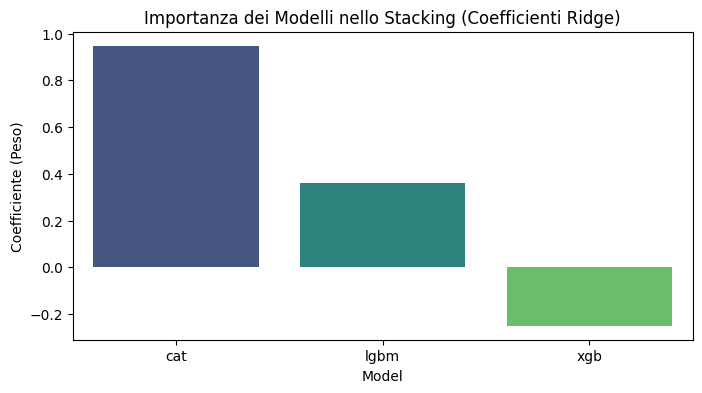


--- Top Features (dal miglior modello base: XGB) ---
MedInc        0.525646
AveOccup      0.146799
Longitude     0.083506
HouseAge      0.068882
Latitude      0.066593
AveRooms      0.064796
AveBedrms     0.031047
Population    0.012732
dtype: float32


In [28]:
# Creiamo un DataFrame per visualizzarli bene
weights_df = pd.DataFrame({
    'Model': model_names,
    'Weight': coefficients
}).sort_values(by='Weight', ascending=False)

print(weights_df)
print(f"\nIntercept (Bias): {meta_model.intercept_:.4f}")

# Grafico a Barre dei Pesi
plt.figure(figsize=(8, 4))
sns.barplot(x='Model', y='Weight', data=weights_df, palette='viridis')
plt.title('Importanza dei Modelli nello Stacking (Coefficienti Ridge)')
plt.ylabel('Coefficiente (Peso)')
plt.show()

# --- 6.2 Top Features Assolute ---
print("\n--- Top Features (dal miglior modello base: XGB) ---")
# Recuperiamo XGBoost dall'ensemble addestrato
xgb_fitted = stacking.estimators_[0] 
importances = pd.Series(xgb_fitted.feature_importances_, index=X_train.columns)
print(importances.sort_values(ascending=False).head(10))